## Loading Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/retail_store_sales_cleaned.csv")

df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,business_rule_valid
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,True
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,Unknown,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,True


## Data Overview

In [3]:
df.shape

(12575, 12)

In [4]:
df.describe()

,price_per_unit,quantity,total_spent
count,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,130.208111
std,10.480413,2.790160,93.580667
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,52.000000
50%,23.000000,6.000000,110.000000
75%,32.000000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       12575 non-null  str    
 1   customer_id          12575 non-null  str    
 2   category             12575 non-null  str    
 3   item                 12575 non-null  str    
 4   price_per_unit       12575 non-null  float64
 5   quantity             12575 non-null  int64  
 6   total_spent          12575 non-null  float64
 7   payment_method       12575 non-null  str    
 8   location             12575 non-null  str    
 9   transaction_date     12575 non-null  str    
 10  discount_applied     12575 non-null  str    
 11  business_rule_valid  12575 non-null  bool   
dtypes: bool(1), float64(2), int64(1), str(8)
memory usage: 1.1 MB


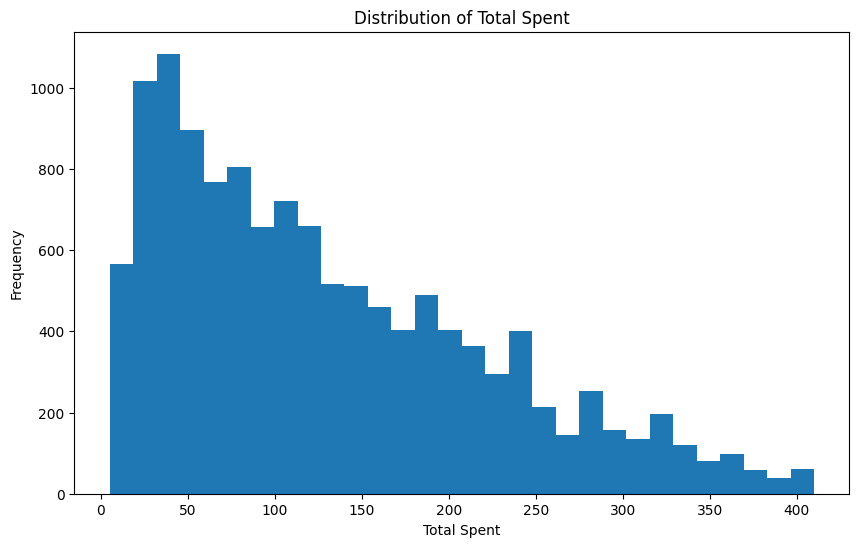

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df['total_spent'], bins=30)
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency') 
plt.show()

### The distribution of transaction values is positively skewed (right-skewed). Most purchases fall within the lower spending range, while high-value transactions occur less frequently.


## Category Distribution

In [7]:
df['category'].value_counts()


category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

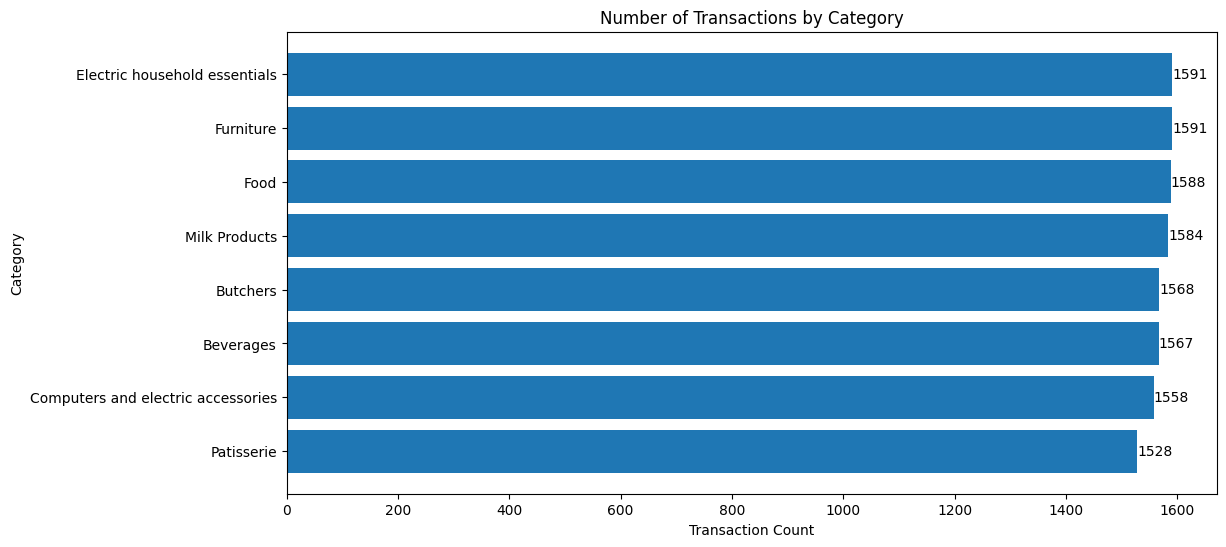

In [8]:
category_counts = (
    df['category']
      .value_counts()
      .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    category_counts.index,
    category_counts.values
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.title('Number of Transactions by Category')
plt.xlabel('Transaction Count')
plt.ylabel('Category')
plt.show()

# Revenue Analysis

## Revenue by Category

In [9]:
category_sales = (
    df.groupby('category')['total_spent'].sum().sort_values())
category_sales


category
Milk Products                         189892.0
Patisserie                            194531.5
Computers and electric accessories    202023.5
Food                                  205225.0
Furniture                             205390.0
Beverages                             206854.5
Electric household essentials         215297.5
Butchers                              218153.0
Name: total_spent, dtype: float64

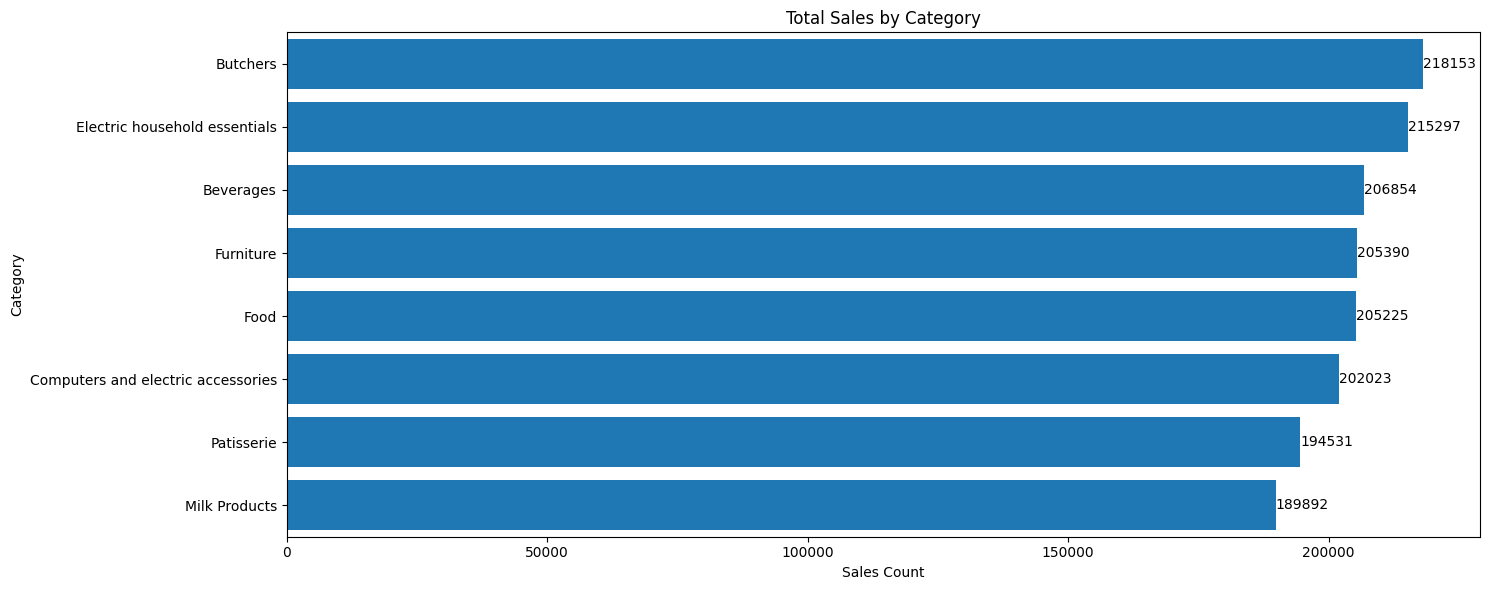

In [10]:
category_sales.plot(kind='barh', figsize=(15,6))
bars = plt.barh(
    category_sales.index,
    category_sales.values
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.title('Total Sales by Category')    
plt.xlabel('Sales Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


## Revenue by Location

In [11]:
location_sales = (
        df.groupby('location')['total_spent'].sum().sort_values())
location_sales

location
In-store    805445.0
Online      831922.0
Name: total_spent, dtype: float64

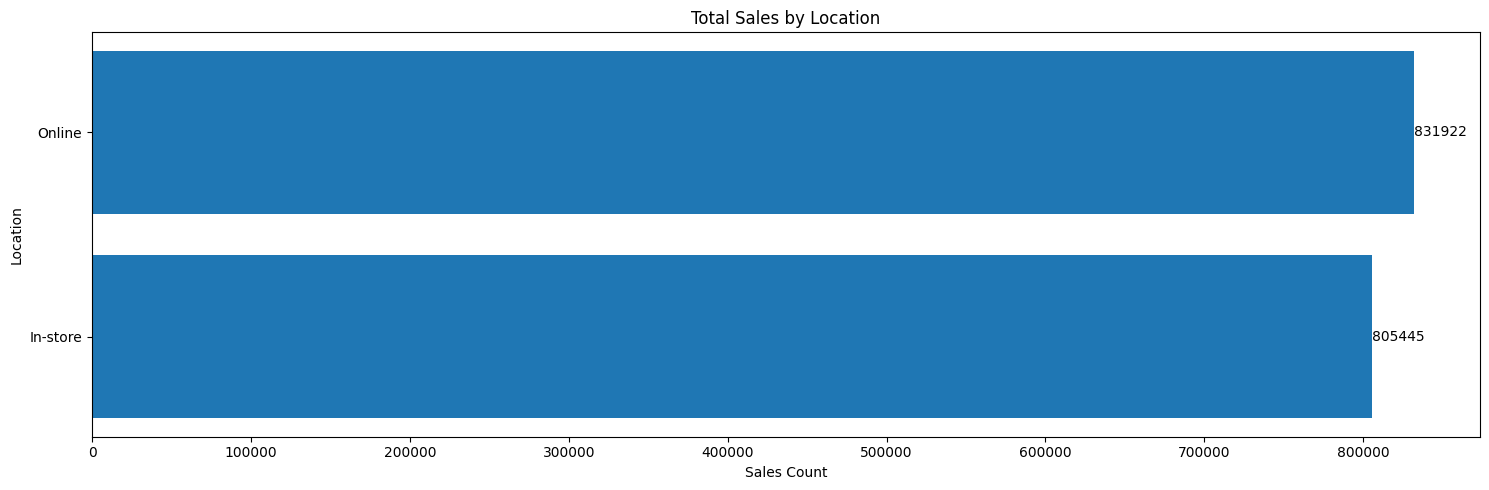

In [12]:
plt.figure(figsize=(15,5))

bars = plt.barh(
    location_sales.index,
    location_sales.values
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.title('Total Sales by Location')
plt.xlabel('Sales Count')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

## Product Analysis

In [13]:
top_products = (
    df[df['item'] != 'Unknown'].groupby('item')['total_spent'].sum().sort_values(ascending=False).head(10)
)
top_products

item
Item_25_FUR     25256.0
Item_25_EHE     23083.0
Item_25_BUT     21894.0
Item_24_FUR     21172.0
Item_25_FOOD    20541.0
Item_22_BUT     19710.0
Item_23_BUT     19114.0
Item_20_BUT     18860.5
Item_19_MILK    18848.0
Item_23_EHE     18468.0
Name: total_spent, dtype: float64

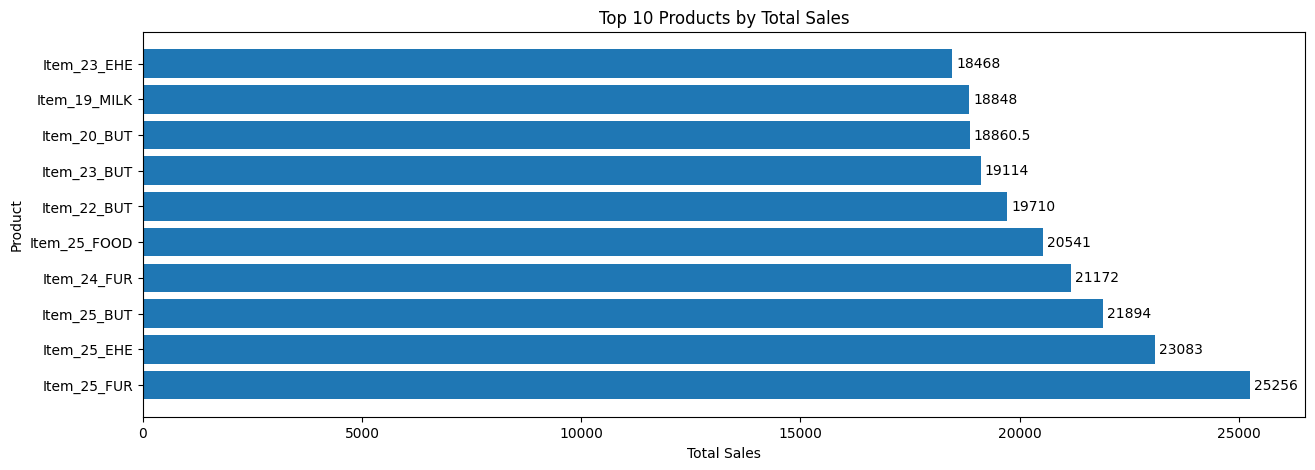

In [14]:
fig, ax = plt.subplots(figsize=(15,5))
bars = ax.barh(top_products.index, top_products.values)

ax.bar_label(bars, padding=3)
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.show()


## Payment Method Analysis

In [15]:
payment_method_sales = (
    df.groupby('payment_method')['total_spent'].sum().sort_values(ascending=False))
payment_method_sales

payment_method
Cash              567275.0
Digital Wallet    535617.0
Credit Card       534475.0
Name: total_spent, dtype: float64

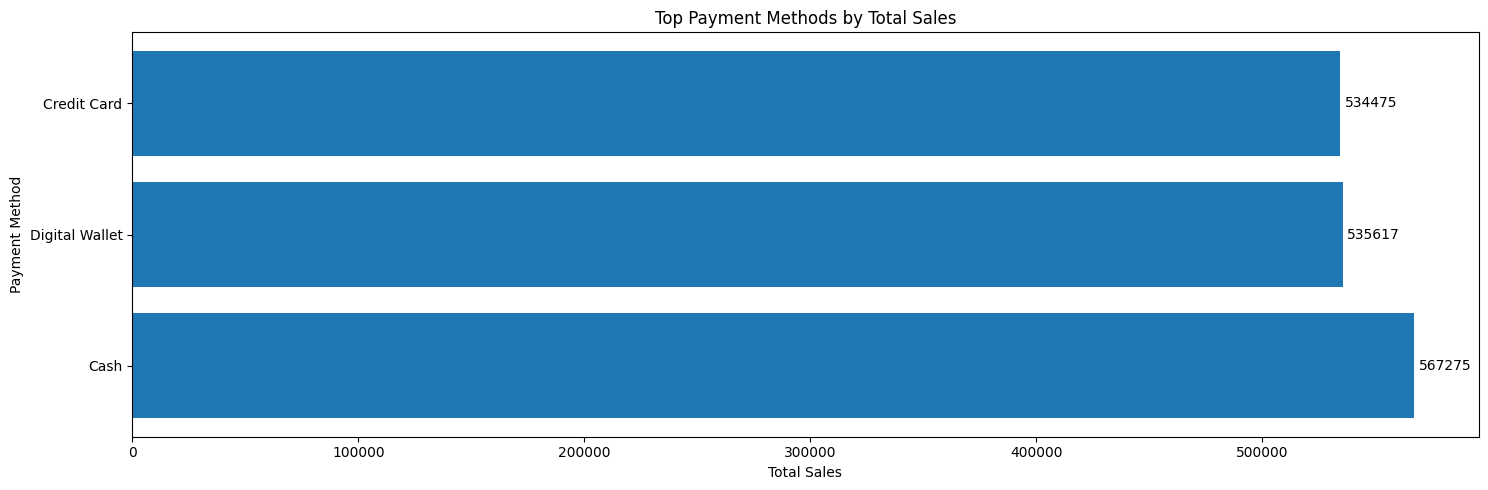

In [16]:
fig, ax = plt.subplots(figsize=(15,5))
bars = ax.barh(payment_method_sales.index, payment_method_sales.values)

ax.bar_label(bars, padding=3)
plt.title('Top Payment Methods by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()


## Discount Analysis

In [17]:
discount_sales = (
    df.groupby('discount_applied')['total_spent']
      .mean()
      .sort_values()
)
discount_sales

discount_applied
Unknown    128.856990
False      130.796728
True       130.972861
Name: total_spent, dtype: float64

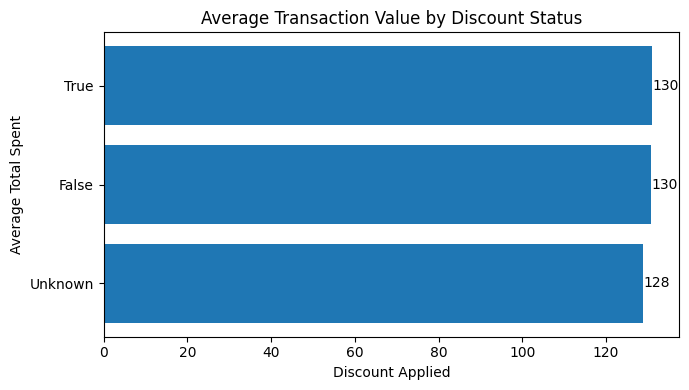

In [18]:
plt.figure(figsize=(7,4))

bars = plt.barh(
    discount_sales.index,
    discount_sales.values
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.title('Average Transaction Value by Discount Status')
plt.xlabel('Discount Applied')
plt.ylabel('Average Total Spent')
plt.tight_layout()
plt.show()

Discounts do not appear to have a meaningful impact on average transaction value in this dataset.

## Time Series Analysis

In [19]:
monthly_sales = (
    df.groupby(pd.to_datetime(df['transaction_date']).dt.to_period('M'))['total_spent'].sum().sort_values()                      
)
monthly_sales


transaction_date
2025-01    26967.5
2023-11    38715.0
2024-02    40001.0
2023-08    40080.0
2023-10    40320.0
2022-10    40422.0
2023-04    41056.5
2023-02    41392.5
2023-03    41405.5
2022-12    41507.0
2022-05    42066.5
2023-05    42490.5
2022-04    42584.0
2024-07    42719.0
2023-09    43028.0
2022-03    43225.0
2022-08    43415.5
2024-09    43952.5
2023-06    44061.0
2022-06    44481.0
2024-10    45085.5
2024-03    45213.5
2022-11    45366.5
2023-12    45406.0
2024-11    46020.0
2024-08    46161.0
2022-02    46268.5
2024-06    47364.0
2022-07    47453.5
2024-05    47519.5
2022-09    47541.5
2023-07    48191.5
2024-04    48524.0
2023-01    49354.5
2024-12    50692.5
2024-01    51043.5
2022-01    56271.5
Freq: M, Name: total_spent, dtype: float64

## Monthly

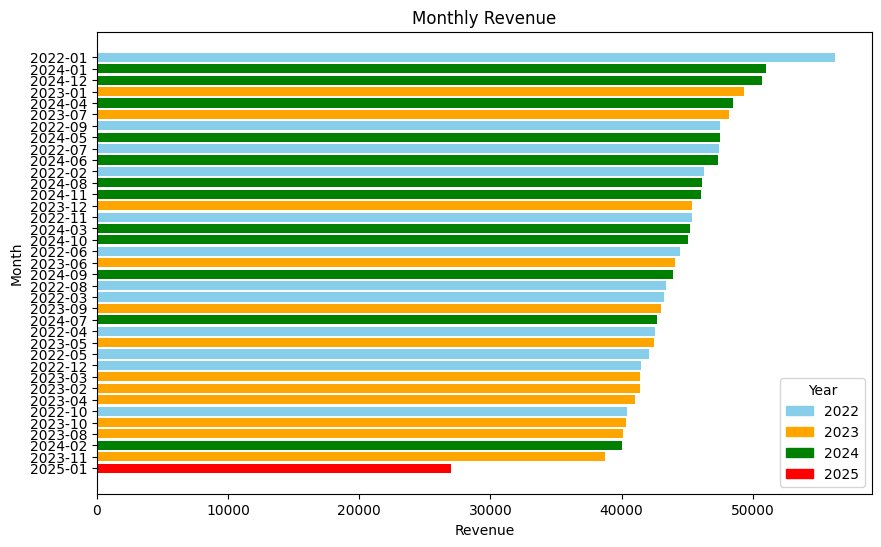

In [20]:
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,6))

# Extract years from index
years = [date.split('-')[0] for date in monthly_sales.index]

# Color mapping
color_map = {
    '2022': 'skyblue',
    '2023': 'orange',
    '2024': 'green',
    '2025': 'red'
}

colors = [color_map[year] for year in years]


plt.barh(
    monthly_sales.index,
    monthly_sales.values,
    color=colors
)

plt.title("Monthly Revenue")
plt.xlabel("Revenue")
plt.ylabel("Month")
plt.legend(handles=[plt.Rectangle((0,0),1,1,color=color_map[year]) for year in color_map], labels=color_map.keys(), title='Year')
plt.show()

## Quaterly

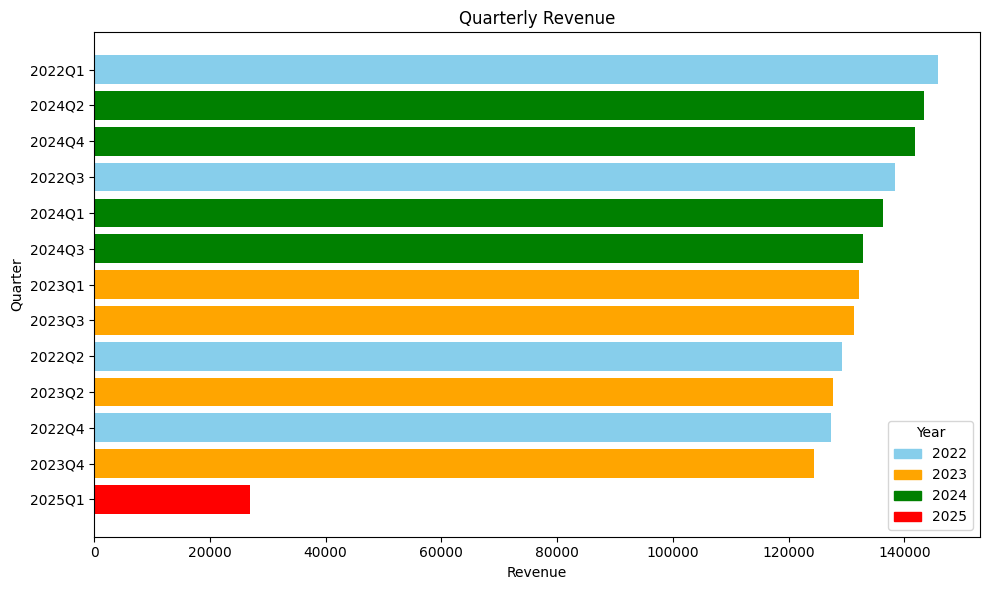

In [21]:
quarterly_sales = (
    df.groupby(pd.to_datetime(df['transaction_date']).dt.to_period('Q'))['total_spent'].sum().sort_values()                      
)
quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(10,6))

# Extract year from quarter string
years = [q[:4] for q in quarterly_sales.index]

# Assign colors
color_map = {
    '2022': 'skyblue',
    '2023': 'orange',
    '2024': 'green',
    '2025': 'red'
}

colors = [color_map[year] for year in years]

plt.barh(
    quarterly_sales.index,
    quarterly_sales.values,
    color=colors
)

plt.title("Quarterly Revenue")
plt.xlabel("Revenue")
plt.ylabel("Quarter")
plt.tight_layout()
plt.legend(handles=[plt.Rectangle((0,0),1,1,color=color_map[year]) for year in color_map], labels=color_map.keys(), title='Year')
plt.show()

### The low value for 2025 Q1 is caused by incomplete data coverage rather than a business decline.

## Yearly

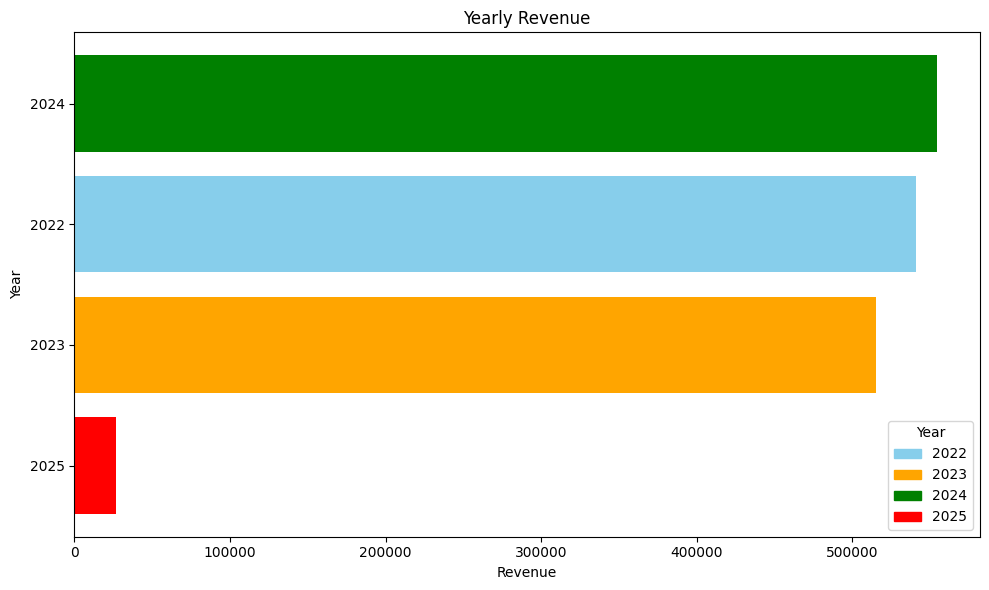

In [22]:
yearly_sales = (
    df.groupby(pd.to_datetime(df['transaction_date']).dt.to_period('Y'))['total_spent'].sum().sort_values()                      
)
yearly_sales.index = yearly_sales.index.astype(str)

plt.figure(figsize=(10,6))

# Assign colors
color_map = {
    '2022': 'skyblue',
    '2023': 'orange',
    '2024': 'green',
    '2025': 'red'
}

colors = [color_map[year] for year in yearly_sales.index]

plt.barh(
    yearly_sales.index,
    yearly_sales.values,
    color=colors
)

plt.title("Yearly Revenue")
plt.xlabel("Revenue")
plt.ylabel("Year")
plt.legend(handles=[plt.Rectangle((0,0),1,1,color=color_map[year]) for year in color_map], labels=color_map.keys(), title='Year')
plt.tight_layout()
plt.show()

## Revenue Share by Category

In [28]:
category_share = (
    df.groupby('category')['total_spent'].sum().sort_values(ascending=False)
)

share = (category_share / category_share.sum() * 100).round(2)

pd.DataFrame({
    'Revenue': category_share,
    'Share (%)': share
})

,Revenue,Share (%)
category,,
Butchers,218153.0,13.32
Electric household essentials,215297.5,13.15
Beverages,206854.5,12.63
Furniture,205390.0,12.54
Food,205225.0,12.53
Computers and electric accessories,202023.5,12.34
Patisserie,194531.5,11.88
Milk Products,189892.0,11.60


Top 3 categories

In [29]:
pd.DataFrame({
    'Revenue': category_share,
    'Share (%)': share
}).head(3)

,Revenue,Share (%)
category,,
Butchers,218153.0,13.32
Electric household essentials,215297.5,13.15
Beverages,206854.5,12.63


## Average Transaction Value by Category

In [34]:
avg_order_value = df.groupby('category')['total_spent'].mean().sort_values(ascending=False)
avg_order_value

category
Butchers                              139.128189
Electric household essentials         135.322124
Beverages                             132.006701
Computers and electric accessories    129.668485
Food                                  129.234887
Furniture                             129.094909
Patisserie                            127.311191
Milk Products                         119.881313
Name: total_spent, dtype: float64

Average transaction values are relatively consistent across categories, ranging from approximately 120 to 139. This suggests that customers tend to spend similar amounts per transaction regardless of product category. However, Butchers and Electric Household Essentials generate slightly higher-value purchases on average.

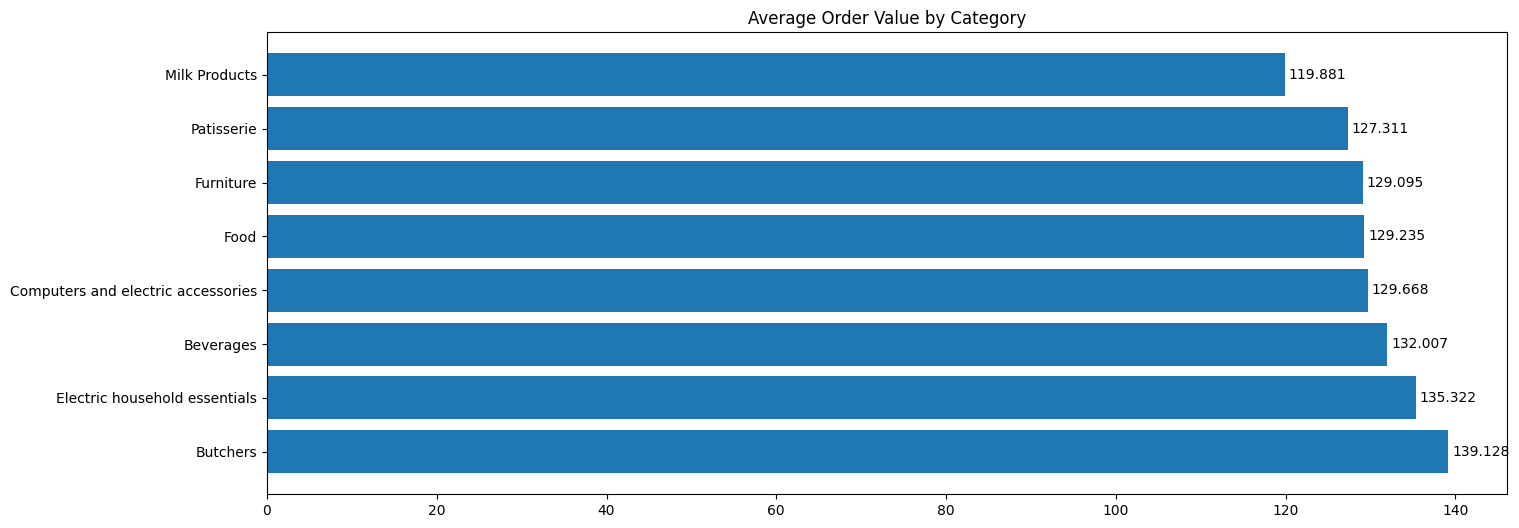

In [38]:
fig, ax = plt.subplots(figsize=(16,6))
bars = ax.barh(avg_order_value.index, avg_order_value.values)
ax.bar_label(bars, padding=3)
plt.title('Average Order Value by Category')
plt.show()  

## Quatity sold by Category

In [39]:
quantity_sold = df.groupby('category')['quantity'].sum().sort_values(ascending=False)
quantity_sold

category
Food                                  8873
Furniture                             8858
Beverages                             8784
Milk Products                         8765
Electric household essentials         8759
Computers and electric accessories    8758
Butchers                              8638
Patisserie                            8465
Name: quantity, dtype: int64

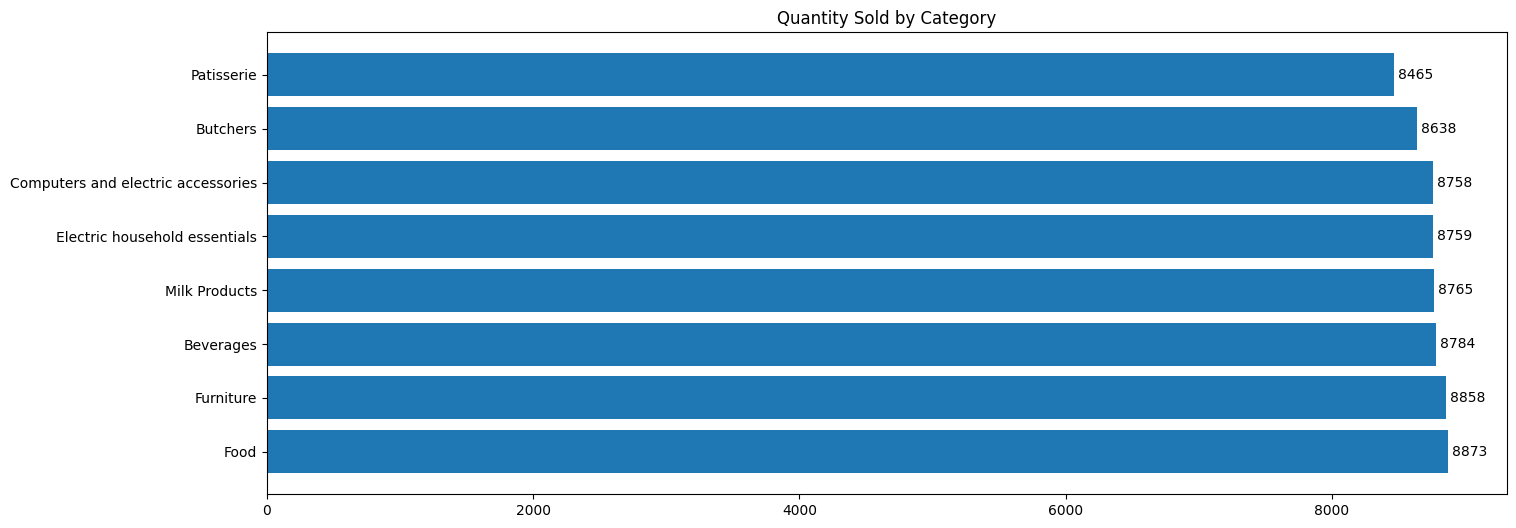

In [40]:
fig, ax = plt.subplots(figsize=(16,6))
bars = ax.barh(quantity_sold.index, quantity_sold.values)
ax.bar_label(bars, padding=3)
plt.title('Quantity Sold by Category')
plt.show()  

Food sells the most units while Butchers generates higher revenue per unit

## Customer Analysis

In [41]:
df['customer_id'].nunique()

25

In [42]:
top_customers = (
    df.groupby('customer_id')['total_spent'].sum().sort_values(ascending=False).head(10)
)
top_customers

customer_id
CUST_24    71890.0
CUST_08    70822.5
CUST_05    70631.5
CUST_13    68904.0
CUST_23    68554.0
CUST_16    68225.5
CUST_10    66419.5
CUST_22    65980.5
CUST_15    65601.5
CUST_21    65366.0
Name: total_spent, dtype: float64

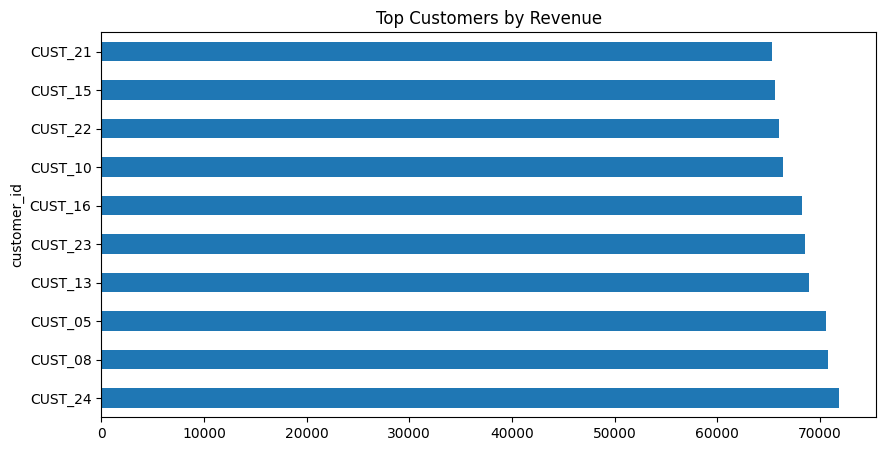

In [43]:
top_customers.plot(kind='barh', figsize=(10,5))
plt.title('Top Customers by Revenue')
plt.show()

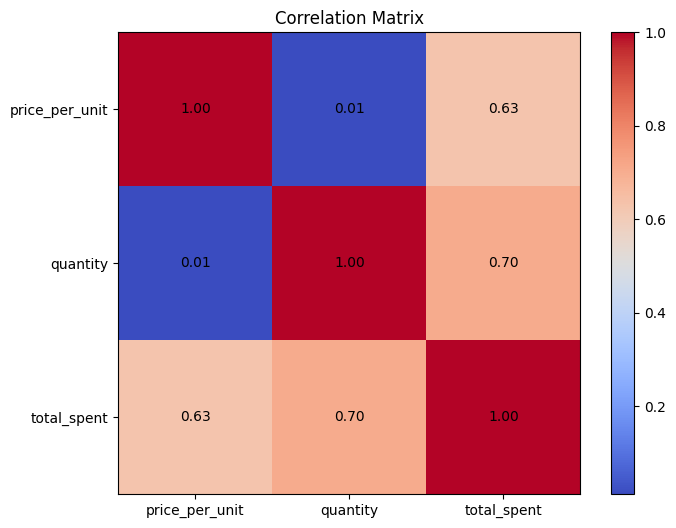

In [44]:
corr = df[['price_per_unit','quantity', 'total_spent']].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                  ha='center', va='center')
        
plt.colorbar()
plt.title('Correlation Matrix')
plt.show()

Total spent is strongly influenced by quantity and price per unit

## Conclusion

The retail sales dataset was successfully cleaned and validated prior to analysis.

Key findings include:

- Transaction values are right-skewed, with most purchases concentrated in lower spending ranges.
- Revenue is evenly distributed across product categories, with Butchers generating the highest sales.
- Average transaction values remain consistent across categories.
- Online sales slightly exceed in-store sales.
- Discounts do not appear to significantly influence customer spending behavior.
- Sales remain stable across months and quarters, with no strong evidence of seasonality.
- Four records were flagged during business-rule validation due to missing values that required median imputation.

The cleaned dataset is suitable for reporting, dashboarding, and further business analysis.